In [ ]:
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import seaborn as sns

FEAT_DIR = os.path.join(os.getcwd(),'features')
# --- TODO: Load Sequence Data ---
# HINT: Use np.load() to bring in your .npy files from the features directory.
X = np.load(os.path.join(FEAT_DIR, 'temporal_sequences.npy')) 
y = np.load(os.path.join(FEAT_DIR, 'y_labels.npy'))

# --- TODO: Normalize the Temporal Data ---
# HINT: LSTMs are sensitive to large values. 
# 1. Capture the original shape: (N, TimeSteps, Features)
# 2. Reshape to 2D: (N * TimeSteps, Features)
# 3. Apply StandardScaler()
# 4. Reshape back to (N, TimeSteps, Features)
scaler = StandardScaler()
X_flatten = X.reshape(-1, X.shape[-1])
X_scaled_2d = scaler.fit_transform(X_flatten)
X_final = X_scaled_2d.reshape(X.shape[0], X.shape[1], X.shape[2])



# --- TODO: One-Hot Encoding ---
# HINT: Use tf.keras.utils.to_categorical(y, num_classes=10)
# This maps integers (e.g., 3) to vectors (e.g., [0,0,0,1,0,0,0,0,0,0])
y_onehot = to_categorical(y, num_classes=10)
# --- TODO: Split the Data ---
# HINT: Standard 80/20 split. 
# Use stratify=y to prevent the model from becoming biased toward one genre.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y_onehot, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # HINT: Use the original integer labels for stratification logic
)
print(f"Dorsal Input Shape: {X_train.shape}") # Goal: (Samples, 130, 20)

Dorsal Input Shape: (7984, 130, 20)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
# --- TODO: Initialize the Sequential Model ---
# HINT: This is the 'shell' where you will stack your layers.
model = tf.keras.Sequential()

# --- TODO: Add the First LSTM Layer ---
# HINT: 1. Set 'units' (try 64 or 128). 
# HINT: 2. Crucial: Set 'input_shape' to (TimeSteps, Features) – look at X_train.shape[1:].
# HINT: 3. Because we are stacking LSTMs, set 'return_sequences=True'.
model.add(tf.keras.layers.LSTM(128, input_shape=(130, 20), return_sequences=True))

# --- TODO: Add Regularization ---
# HINT: 1. Add BatchNormalization() to help the model learn faster on the cluster.
# HINT: 2. Add Dropout(0.3) to prevent the "Dorsal Stream" from over-memorizing noise.
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.3))

# --- TODO: Add the Second LSTM Layer ---
# HINT: This is your summary layer. Set 'return_sequences=False'.
# This condenses the temporal patterns into a single high-level vector.
model.add(tf.keras.layers.LSTM(64, return_sequences=False))

# --- TODO: Add the Decision Layer ---
# HINT: 1. This must be a 'Dense' layer.
# HINT: 2. Use 10 neurons (one for each genre).
# HINT: 3. Use 'softmax' activation to get probabilities.
model.add(tf.keras.layers.Dense(10, activation='softmax'))
d
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics= ['accuracy'])
d
model.summary()

E0000 00:00:1778761852.496279  162670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ulas/Uni/Neuroinformatik/Music_Classification_Project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 130, 128)       │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,858 (495.54 KB)

 Trainable params: 126,602 (494.54 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:

history = model.fit(
    X_train, 
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test), 
    shuffle=True
)

MODEL_DIR = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

model.save(os.path.join(MODEL_DIR, 'dorsal_specialist_lstm.keras'))

Epoch 1/50


W0000 00:00:1778761977.561362  162670 cpu_allocator_impl.cc:82] Allocation of 83033600 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 184ms/step - accuracy: 0.4579 - loss: 1.5627 - val_accuracy: 0.4917 - val_loss: 1.4093
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 172ms/step - accuracy: 0.5555 - loss: 1.2835 - val_accuracy: 0.5618 - val_loss: 1.2311
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.6130 - loss: 1.1195 - val_accuracy: 0.5694 - val_loss: 1.1871
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 174ms/step - accuracy: 0.6432 - loss: 1.0265 - val_accuracy: 0.6274 - val_loss: 1.0536
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 171ms/step - accuracy: 0.6827 - loss: 0.9121 - val_accuracy: 0.6810 - val_loss: 0.9274
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 175ms/step - accuracy: 0.7127 - loss: 0.8397 - val_accuracy: 0.6780 - val_loss: 0.9525
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7365 - loss: 0.7601 - val_accuracy: 0.7031 - val_loss: 0.8764
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 173ms/step - accuracy: 0.7467 - loss: 0.7416 - val

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step
              precision    recall  f1-score   support

       blues       0.88      0.83      0.86       200
   classical       0.95      0.92      0.94       200
     country       0.81      0.73      0.77       199
       disco       0.68      0.78      0.73       200
      hiphop       0.82      0.84      0.83       200
        jazz       0.77      0.90      0.83       198
       metal       0.89      0.92      0.90       200
         pop       0.88      0.83      0.86       200
      reggae       0.83      0.79      0.81       200
        rock       0.75      0.69      0.72       200

    accuracy                           0.82      1997
   macro avg       0.83      0.82      0.82      1997
weighted avg       0.83      0.82      0.82      1997



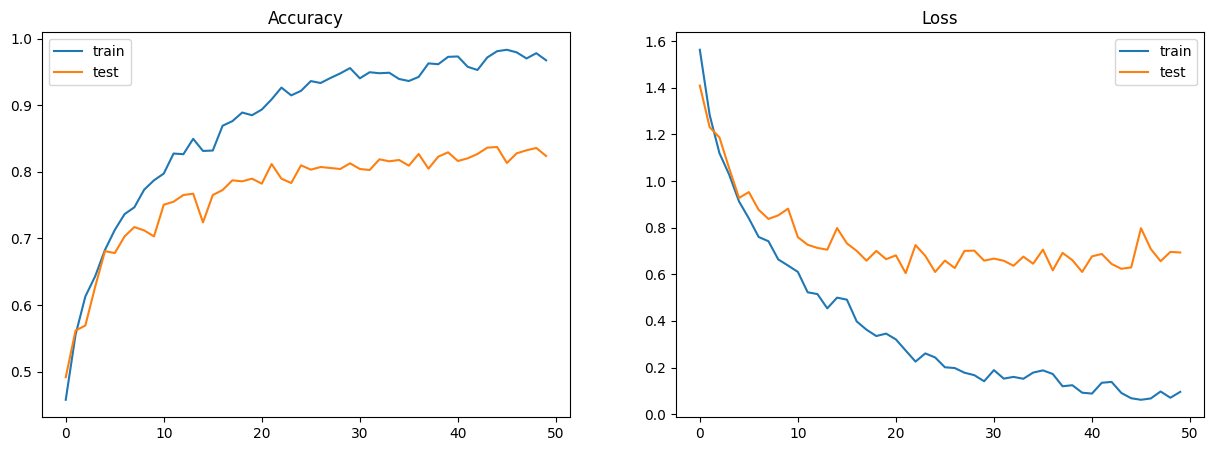

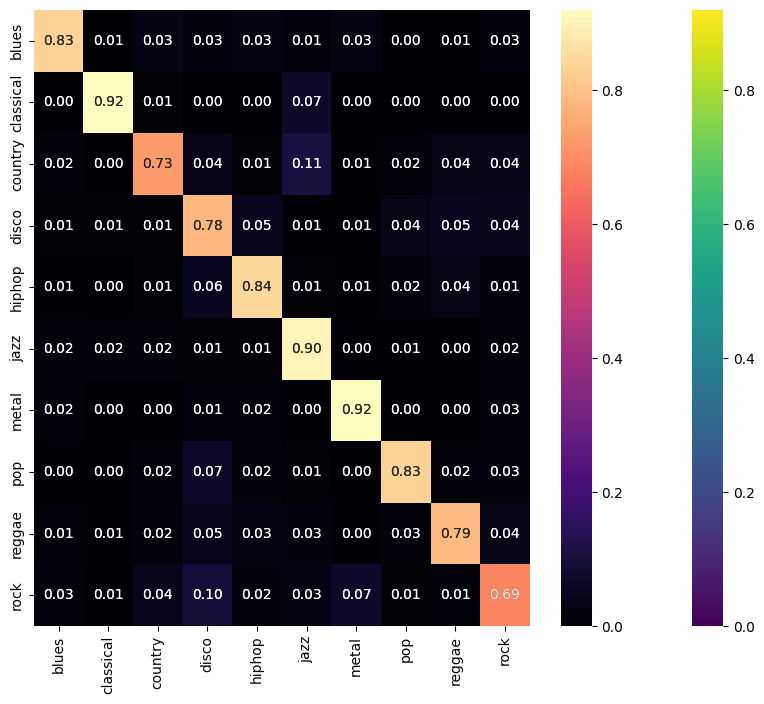

In [ ]:
import os
import matplotlib
matplotlib.use('Agg') # Necessary to prevent crashes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Silent Predictions
y_pred_probs = model.predict(X_test, verbose=0) # verbose=0 stops the progress bar
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
          'jazz', 'metal', 'pop', 'reggae', 'rock']

# 2. Save Performance Plots (No printing/showing)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
plt.savefig('training_curves.png')
plt.close()

# 3. Save Confusion Matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=genres, yticklabels=genres, cmap='magma')
plt.savefig('confusion_matrix.png')
plt.close()

# 4. Silent Model Save
model.save('models/dorsal_specialist.keras')